In [1]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
os.chdir('../')

In [3]:
df = pd.read_csv('data/Titanic-Dataset.csv', sep=',')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1. Análise Exploratória

dataframe geral

In [5]:
print(df.shape)

(891, 12)


In [6]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
print(df.duplicated().sum())

0


por coluna

In [9]:
# Label
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [10]:
print(df['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


In [11]:
print(df['SibSp'].value_counts())

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


In [12]:
print(df['Parch'].value_counts())

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


In [13]:
print(df['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


histogramas

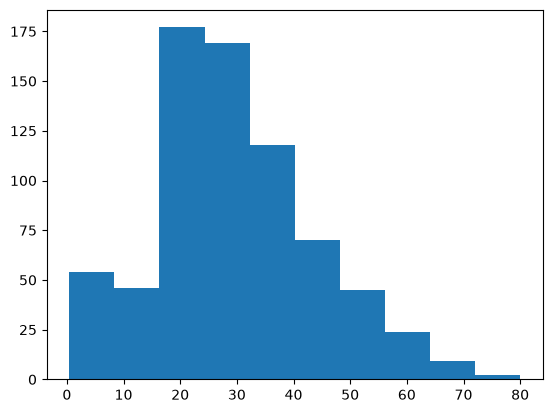

In [14]:
plt.hist(df['Age'])
plt.show()

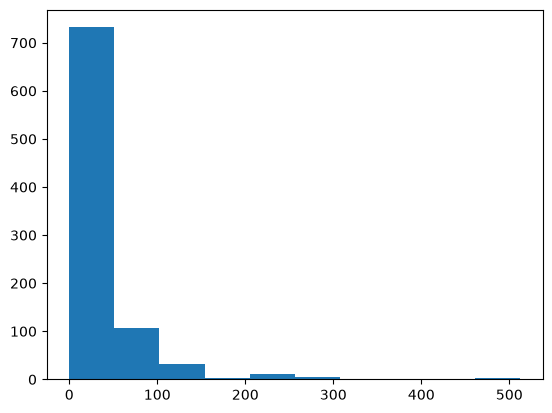

In [15]:
plt.hist(df['Fare'])
plt.show()

outliers

In [16]:
# Coluna Age
age_Q1 = df['Age'].quantile(0.25)
age_Q3 = df['Age'].quantile(0.75)

print(age_Q1, age_Q3)

20.125 38.0


In [17]:
age_IQR = age_Q3 - age_Q1
print(age_IQR)

17.875


In [18]:
lower_limit = age_Q1 - 1.5*age_IQR  # limite mínimo para o primeiro quartil
upper_limit = age_Q3 + 1.5*age_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-6.6875 64.8125


In [19]:
outliers_age = (df['Age'] < lower_limit) | (df['Age'] > upper_limit)
print(outliers_age.sum())

11


In [20]:
# Coluna Fare
fare_Q1 = df['Fare'].quantile(0.25)
fare_Q3 = df['Fare'].quantile(0.75)

print(fare_Q1, fare_Q3)

7.9104 31.0


In [21]:
fare_IQR = fare_Q3 - fare_Q1
print(fare_IQR)

23.0896


In [22]:
lower_limit = fare_Q1 - 1.5*fare_IQR  # limite mínimo para o primeiro quartil
upper_limit = fare_Q3 + 1.5*fare_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-26.724 65.6344


In [23]:
outliers_fare = (df['Fare'] < lower_limit) | (df['Fare'] > upper_limit)
print(outliers_fare.sum())

116


### 2. Train-Test Split

In [24]:
X_data = df.drop(columns=['Survived'])
y_data = df['Survived']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

### Conjunto de Treino

### 3. Pré-Processamento

#### 3.1. Tratamento de Outliers

In [26]:
# Coluna Age
age_Q1 = X_train['Age'].quantile(0.25)
age_Q3 = X_train['Age'].quantile(0.75)

print(age_Q1, age_Q3)

20.0 38.0


In [27]:
age_IQR = age_Q3 - age_Q1
print(age_IQR)

18.0


In [28]:
lower_limit = age_Q1 - 1.5*age_IQR  # limite mínimo para o primeiro quartil
upper_limit = age_Q3 + 1.5*age_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-7.0 65.0


In [29]:
outliers_age = (X_train['Age'] < lower_limit) | (X_train['Age'] > upper_limit)
print(outliers_age.sum())

5


In [30]:
X_train = X_train[(X_train['Age'] > lower_limit) & (X_train['Age'] < upper_limit)]

In [31]:
# Coluna Fare
fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

print(fare_Q1, fare_Q3)

8.05 34.375


In [32]:
fare_IQR = fare_Q3 - fare_Q1
print(fare_IQR)

26.325


In [33]:
lower_limit = fare_Q1 - 1.5*fare_IQR  # limite mínimo para o primeiro quartil
upper_limit = fare_Q3 + 1.5*fare_IQR  # limite máximo para o terceiro quartil

print(lower_limit, upper_limit)

-31.437499999999996 73.8625


In [34]:
outliers_fare = (X_train['Fare'] < lower_limit) | (X_train['Fare'] > upper_limit)
print(outliers_fare.sum())

60


In [35]:
X_train = X_train[(X_train['Fare'] > lower_limit) & (X_train['Fare'] < upper_limit)]

In [36]:
y_train = y_train[(y_train > lower_limit) & (y_train < upper_limit)]

### 4. Transformação